        # 00 Load LANL

        This notebook is repo-native: it reads the LANL training CSV from `data/train.csv`,
        uses the real `src/io.py` loader, and saves derived artifacts back into the repository.
        


In [1]:
        from pathlib import Path
        import sys

        REPO_ROOT = Path.cwd().resolve()
        if not (REPO_ROOT / "src").exists():
            REPO_ROOT = REPO_ROOT.parent

        DATA_PATH = REPO_ROOT / "data" / "train.csv"
        OUTPUT_DIR = REPO_ROOT / "results" / "lanl"
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

        INSPECTION_NROWS = 200_000
        PLOT_NROWS = 20_000

        print(f"Repository root: {REPO_ROOT}")
        print(f"Data path: {DATA_PATH}")
        print(f"Inspection subset rows: {INSPECTION_NROWS:,}")
        print("Note: 1,000 rows may not contain a time_to_failure reset, so notebook 01 can expand the subset automatically.")
        


Repository root: C:\Users\carla\Desktop\EECE 798K\Project
Data path: C:\Users\carla\Desktop\EECE 798K\Project\data\train.csv
Inspection subset rows: 200,000
Note: 1,000 rows may not contain a time_to_failure reset, so notebook 01 can expand the subset automatically.


In [2]:
        import matplotlib.pyplot as plt
        import pandas as pd

        sys.path.insert(0, str(REPO_ROOT))

        from src import io, preprocess
        


In [3]:
        if not DATA_PATH.exists():
            raise FileNotFoundError(
                f"Expected LANL data at {DATA_PATH}. Place the Kaggle train.csv there before running the notebooks."
            )

        raw_df = io.load_lanl_train(str(DATA_PATH), nrows=INSPECTION_NROWS)
        cleaned_df = preprocess.clean_lanl_dataframe(raw_df)

        subset_reset_count = int((cleaned_df["time_to_failure"].diff() > 0).sum())
        print(f"Loaded subset shape: {cleaned_df.shape}")
        print(f"Resets found in inspection subset: {subset_reset_count}")
        print(cleaned_df.head())
        


Loaded subset shape: (200000, 3)
Resets found in inspection subset: 0
   time  acoustic_data  time_to_failure
0   0.0             12           1.4691
1   1.0              6           1.4691
2   2.0              8           1.4691
3   3.0              5           1.4691
4   4.0              8           1.4691


In [4]:
        summary = io.describe_dataset(cleaned_df)

        print("Dataset summary:")
        for key, value in summary.items():
            print(f"  {key}: {value}")

        inspection_path = OUTPUT_DIR / "00_loaded_subset.csv"
        cleaned_df.to_csv(inspection_path, index=False)
        print(f"Saved inspection subset to: {inspection_path}")
        


Dataset summary:
  n_samples: 200000
  n_vars: 3
  columns: ['time', 'acoustic_data', 'time_to_failure']
  dtypes: {'time': dtype('float64'), 'acoustic_data': dtype('int64'), 'time_to_failure': dtype('float64')}
  missing_values: {'time': np.int64(0), 'acoustic_data': np.int64(0), 'time_to_failure': np.int64(0)}
  time_col: time
  physical_vars: ['acoustic_data', 'time_to_failure']
Saved inspection subset to: C:\Users\carla\Desktop\EECE 798K\Project\results\lanl\00_loaded_subset.csv


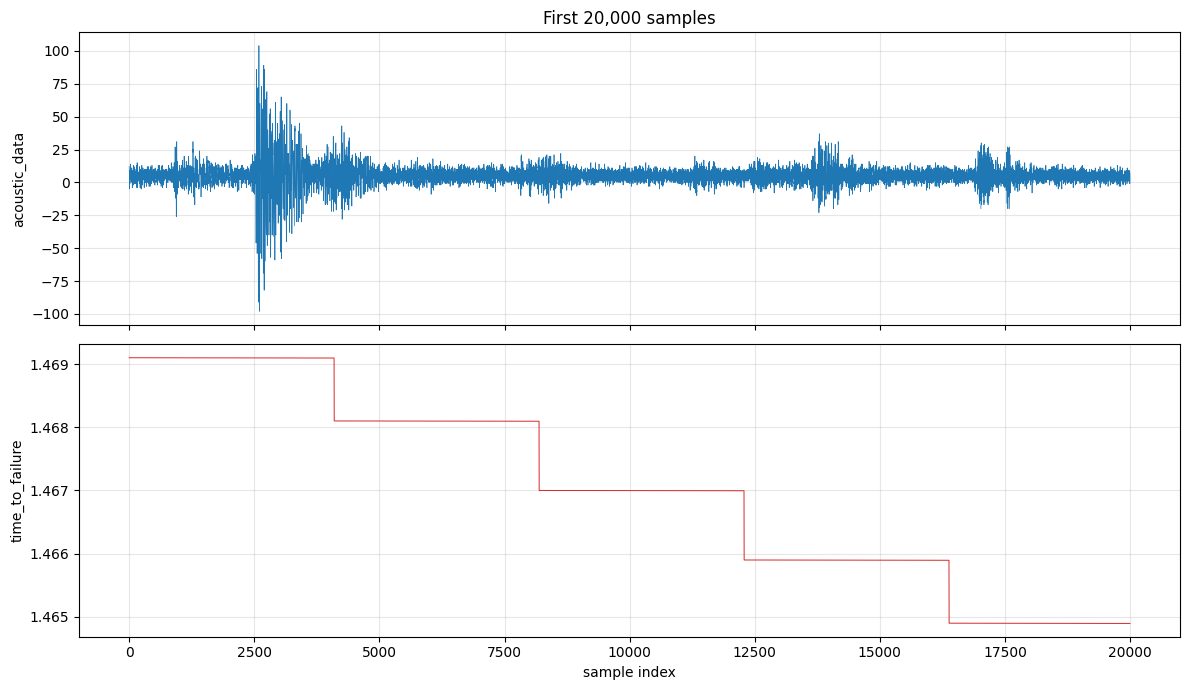

In [5]:
        plot_df = cleaned_df.iloc[:PLOT_NROWS].copy()

        fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
        axes[0].plot(plot_df["time"], plot_df["acoustic_data"], color="tab:blue", linewidth=0.5)
        axes[0].set_ylabel("acoustic_data")
        axes[0].set_title(f"First {len(plot_df):,} samples")
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(plot_df["time"], plot_df["time_to_failure"], color="tab:red", linewidth=0.7)
        axes[1].set_xlabel("sample index")
        axes[1].set_ylabel("time_to_failure")
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        
